### 1. Initialization

Imports and general parameters (from *parameters.py*).

In [1]:
## ----- IPYTHON COMMANDS ----- ##
%load_ext autoreload
%autoreload 2


In [2]:
## ----- IMPORTS ----- ##
import satellite_RFI.src.simulation as sim
import satellite_RFI.src.tools as tools  # <-- might not be necessary
import sys
sys.path.insert(0, './param_import/')
from imports import *
import parameters_graphs as pm


In [3]:
pm.show_parameters()

Block: 1551055211
Frequency range: 1100 - 1350 MHz


### 2. Simulation

Now we're defining a function to create a SatelliteSimulation() for each masking situation.

In [4]:
def simulate(degree=None, temperature=None, pix=None, time_slice=[None,None]):
    ''' Computes the simulation for the given mask (deg,T,pix). '''

    # initializing the function
    if degree is not None:
        path_nearby = (pm.path_data+"nearby_satellites/nearby_satellite_close_angle_"+degree+".p")
    else:  path_nearby = None
    sat = sim.SatelliteSimulation(
        block=str(pm.block),
        use_data=True,
        path_data=pm.path_data,
        path_beam=pm.path_data,
        survey_info=[pm.nd_s0, pm.nd_s0_coords, pm.frequency],
        path_catalog=pm.path_catalog,
        beam_model=pm.beam_model,
        freq_range=[pm.fs, pm.fe],
        freq_slice=[pm.fs_slice, pm.fe_slice],
        include_cons=pm.include_cons,
        verbose=False,
    )
    
    # choose mask
    sat.create_mask(path_nearby, temperature, pix, time_slice, verbose=False)
    return sat


### 3. Figures from the article

#### 3.1 No Masking

We start by storing the values, and later define the functions to plot what we want.

In [5]:
# storing values in arrays
alphas_plot = []
sim_plot = []
CF_plot = []

# creating simulation object
print(f"Simulating for no mask... ",end="")
sat = simulate()
print("done")

# saving some values
obs_plot = np.ma.masked_equal(sat.observations_sat.T,0)
BG_plot = np.ma.masked_equal((sat.observations_BG*sat.mask).T,0)
freq_plot = sat.frequency[sat.ifreq[0]:sat.ifreq[1]]  # <-- same for every mask
times_plot = sat.nd_s0[sat.itime[0]:sat.itime[1]]  # <-- same for every mask

for CF in ["C1","C2"]:
    # calculating
    alphas = pickle.load( open(pm.my_name(CF),'rb') )["best-fit"]
    sat.execute(alphas)

    # saving values
    alphas_plot.append(alphas)
    sim_plot.append(np.ma.masked_equal(sat.simulation.T,0))
    if CF=="C1":  CF_plot.append(sim.CF_radiometer(alphas,sat) / sat.simulation.size )
    elif CF=="C2":  CF_plot.append(sim.CF_unweighted(alphas,sat) / sat.simulation.size )

# defining number of alphas (necessary for plots)
Nalphas = len(alphas_plot[0])


Simulating for no mask... done


In [33]:
# ------------ PLOTTING FUNCTIONS --------------- #

def plot_alphas_nomask(alphas_plot):
    ''' Creates the plot of alpha values for C1 and C2. '''
    
    # plotting values
    fig, ax = plt.subplots(figsize=(10, 4), nrows=1, ncols=1)
    xs = np.arange(1, Nalphas + 1)
    ax.plot(xs, alphas_plot[0], 'o', label=r'$\sigma_D=C_1$')
    ax.plot(xs, alphas_plot[1], '*', label=r'$\sigma_D=C_2$')
    ax.axhline(0, color='black', linestyle='--')

    # creating figure
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xticks(range(1, Nalphas + 1))
    ax.set_title(r'Block: {} No-Mask'.format(pm.block))
    ax.set_xlabel(r'Signal Position $[\alpha_{i}]$')
    ax.set_ylabel('Amplitude')
    ax.legend()
    fig.tight_layout()
    fig.show()

# ----------------------------------------------- #

def plot_1d_nomask(obs_plot, sim_plot, CF_plot):
    ''' Creates the plots for 1d comparison between data and simulation. ''' 

    # creating figures
    fig, axs = plt.subplots(figsize=(20, 4), ncols=2, nrows=1, sharex=True, sharey=True)
    fig.suptitle(r'Block: {} No-Mask'.format(pm.block))

    for i,CF in enumerate(["C_1","C_2"]):
        # plotting values
        ax = axs[i]
        ax.plot(freq_plot, np.ma.mean(obs_plot, axis=0), label='Observation')
        ax.plot(freq_plot, np.ma.mean(sim_plot[i], axis=0), '--', label='Simulation')
        
        # defining figure
        ax.set_ylabel('Temperature [K]')
        ax.set_xlabel('Frequency [MHz]')
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        textstr = "$\\sigma_{{D}}={}$\nFoM={:.2f}".format(CF,CF_plot[i])
        ax.text(0.685, 0.95, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
        ax.legend(loc="upper left")

    # showing figure
    fig.tight_layout()
    fig.show()

# ----------------------------------------------- #

def plot_2d_nomask(obs_plot, sim_plot):
    ''' Creates the plots for 1d comparison between data and simulation. ''' 

    # creating figures
    fig, axs = plt.subplots(figsize=(12, 4), nrows=1, ncols=3, sharey=True)
    fig.suptitle(r'Block: {} No-Mask'.format(pm.block))  
    titles = ['Observation', r'$C_1$', r'$C_2$']
    
    for i,data in enumerate([obs_plot, sim_plot[0], sim_plot[1]]):
        # plotting values
        ax = axs[i]
        cax = ax.imshow(data, aspect='auto', 
                        extent=[freq_plot[0], freq_plot[-1], times_plot[-1], times_plot[0]], 
                        vmax=np.max(obs_plot), vmin=np.min(obs_plot))

        # defining figure
        cbar = fig.colorbar(cax, ax=ax)
        cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
        ax.set_title(titles[i])
        ax.set_ylabel('Time [sec]')
        ax.set_xlabel('Frequency [MHz]')

    # showing figure
    fig.tight_layout()
    fig.show()
    

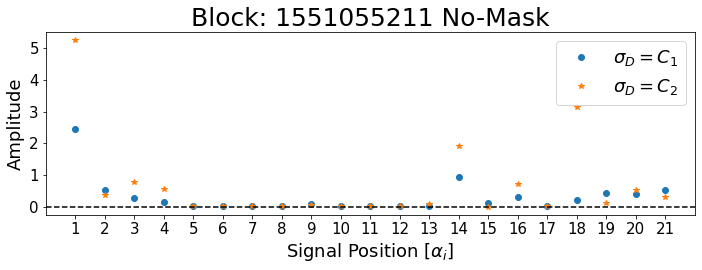

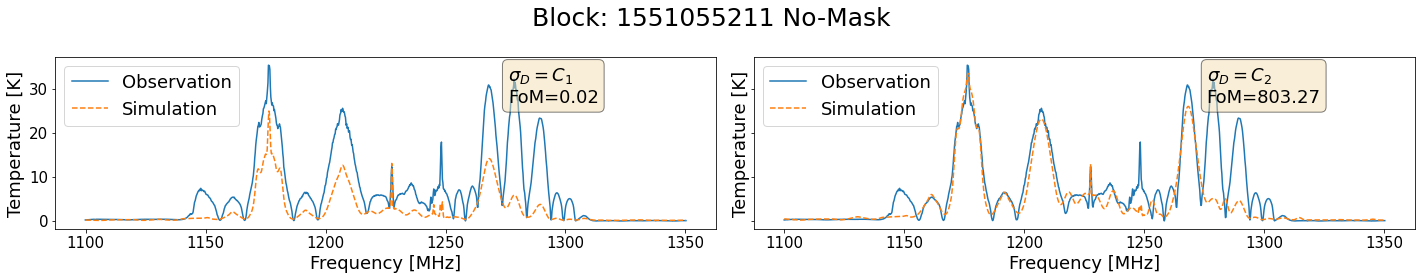

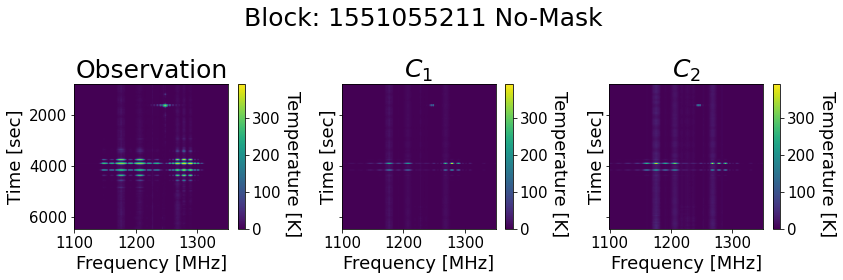

In [34]:
# plotting all things
plot_alphas_nomask(alphas_plot)
plot_1d_nomask(obs_plot, sim_plot, CF_plot)
plot_2d_nomask(obs_plot, sim_plot)

#### 3.2 Angular masking

In [37]:
# storing values in arrays
alphas_plot = {}
sim_plot = {}
CF_plot = {}
obs_plot = {}

for degree in ["1F","5F"]:
    # creating simulation object
    print(f"Simulating for angular mask {degree}... ",end="")
    sat = simulate(degree=degree)
    obs_plot[degree] = np.ma.masked_equal(sat.observations_sat.T,0)
    print("done")
    
    for CF in ["C1","C2"]:
        # calculating
        alphas = pickle.load( open(pm.my_name(CF,degree=degree),'rb') )["best-fit"]
        sat.execute(alphas)
    
        # saving values
        if CF=="C1": 
            alphas_plot[degree] = [alphas]
            sim_plot[degree] = [np.ma.masked_equal(sat.simulation.T,0)]
            CF_plot[degree] = [sim.CF_radiometer(alphas,sat) / sat.mask[sat.mask].size]
        elif CF=="C2":  
            alphas_plot[degree].append(alphas)
            sim_plot[degree].append(np.ma.masked_equal(sat.simulation.T,0))
            CF_plot[degree].append(sim.CF_unweighted(alphas,sat) / sat.mask[sat.mask].size )


Simulating for angular mask 1F... done
Simulating for angular mask 5F... done


In [38]:
## ----- PLOTTING FUNCTIONS ----- ##

def plot_alphas(alphas_plot, labels_mask, title):
    ''' Creates the plot of alpha values for C1 and C2. '''

    # creating figures
    points = ['o', '*', 'x', '.', 'o']
    fig, axs = plt.subplots(figsize=(10, 8), nrows=2, ncols=1, sharey=True)

    # plotting values
    xs = np.arange(1, Nalphas + 1)
    for i,label in enumerate(labels_mask):
        axs[0].plot(xs, alphas_plot[label][0], points[i], label="{}: {}".format(title,label))
        axs[1].plot(xs, alphas_plot[label][1], points[i], label="{}: {}".format(title,label))

    # showing figure
    fig.suptitle(r'Block: {} {} Mask'.format(pm.block,title))
    for i,CF in enumerate(["C_1","C_2"]):
        ax = axs[i]
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.set_xticks(range(1, Nalphas + 1))
        ax.set_ylabel('Amplitude')
        textstr = r"$\sigma_D={}$".format(CF)
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(0.06, 0.95, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
        ax.axhline(0, color='black', linestyle='--')
        ax.legend()
    axs[1].set_xlabel(r'Signal Position $[\alpha_{i}]$')
    
    fig.tight_layout()
    fig.show()

# ----------------------------------- #

def plot_1d(obs_plot, sim_plot, CF_plot, labels_mask, title):
    ''' Creates the plots for 1d comparison between data and simulation. ''' 

    # creating figures
    fig, axs = plt.subplots(figsize=(20, 3*len(labels_mask)), nrows=len(labels_mask), ncols=2, sharey=True)
    fig.suptitle(r'Block {}, {} Mask'.format(pm.block, title))

    for iCF,CF in enumerate(["C_1","C_2"]):
        for ilabel,label in enumerate(labels_mask):
            
            # plotting values
            ax = axs[ilabel,iCF]
            ax.plot(freq_plot, np.ma.mean(obs_plot[label], axis=0), label='Observation')
            ax.plot(freq_plot, np.ma.mean(sim_plot[label][iCF], axis=0), '--', label='Simulation')

            # defining figure
            textstr = "$\\sigma_D={}$\n{}={}\nFoM$={:.3f}$".format(CF,title,label,CF_plot[label][iCF])
            props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
            ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
            if ilabel==1:  ax.set_xlabel('Frequency [MHz]')
            ax.set_ylabel('Temperature [K]')
            ax.legend(loc='upper right')

    # showing figure
    fig.tight_layout()
    fig.show()

# ----------------------------------- #

def plot_2d(obs_plot, sim_plot, labels_mask, title):
    ''' Creates the plots for 2d comparison between data and simulation. ''' 

    # creating figures
    super_titles = ['Observation', r'$C_1$', r'$C_2$']
    fig,axs = plt.subplots(figsize=(16,3+2*len(labels_mask)),nrows=len(labels_mask),ncols=3,sharey=True,sharex=True)
    fig.suptitle("Block {}, {} Mask".format(pm.block, title))

    for ilabel,label in enumerate(labels_mask):
        for idata,data in enumerate([obs_plot[label], sim_plot[label][0], sim_plot[label][1]]):
            # plotting values
            ax = axs[ilabel,idata]
            cax = ax.imshow(data, aspect='auto', 
                            extent=[freq_plot[0], freq_plot[-1], times_plot[-1], times_plot[0]], 
                            vmax=np.max(obs_plot[label]), vmin=np.ma.min(obs_plot[label]))
    
            # defining figure
            cbar = fig.colorbar(cax, ax=ax)
            cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
            ax.set_title(super_titles[idata])
            ax.set_ylabel('Time [sec]')
            ax.set_xlabel('Frequency [MHz]')

    # showing figure
    fig.tight_layout()
    fig.show()
    

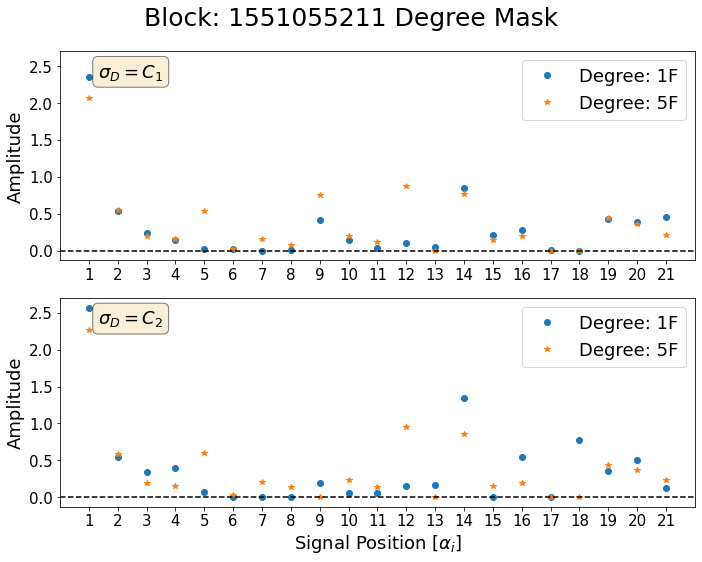

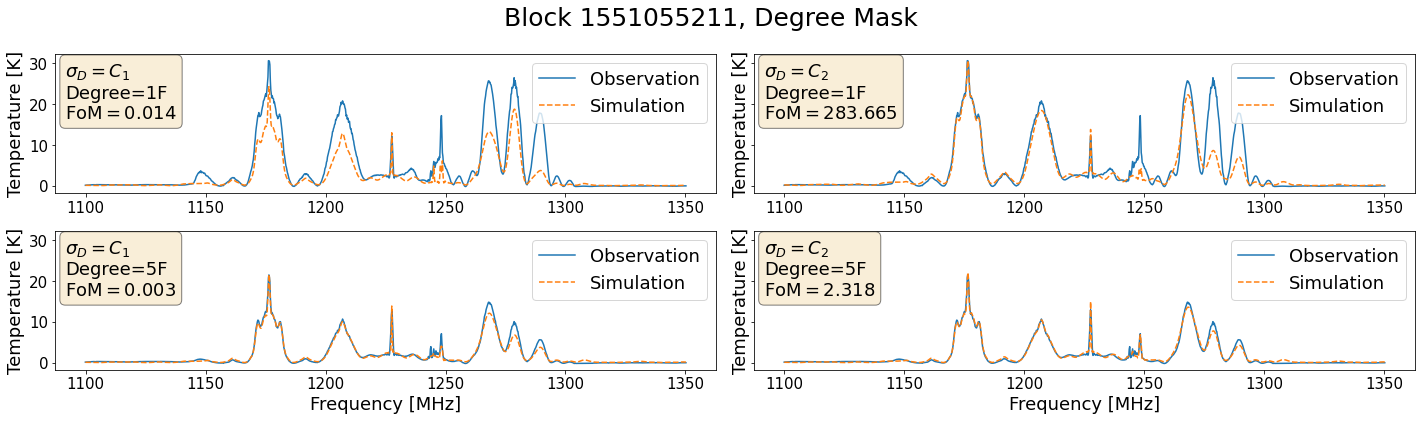

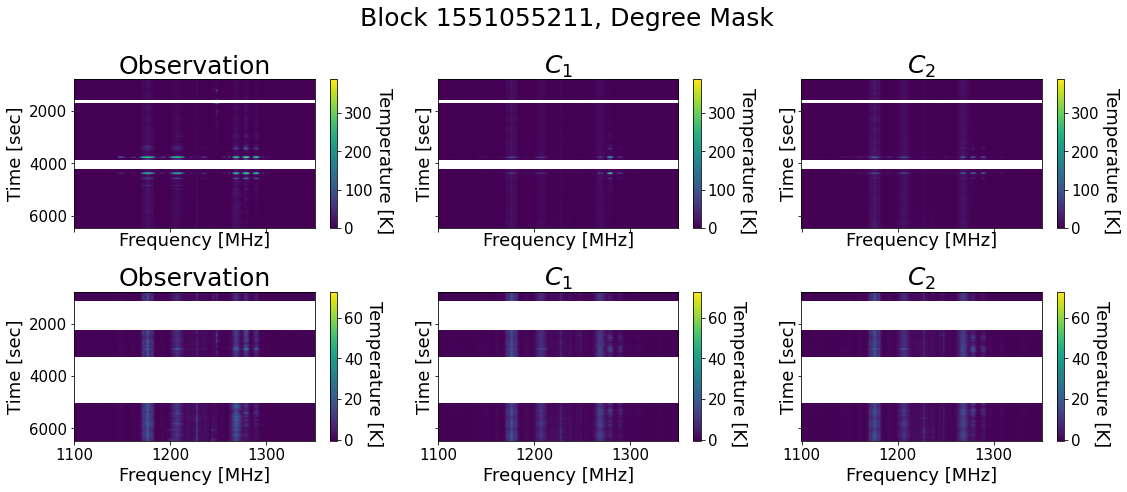

In [39]:
# showing plots
labels_mask = ["1F","5F"]
title = "Degree"
plot_alphas(alphas_plot, ["1F","5F"], "Degree")
plot_1d(obs_plot, sim_plot, CF_plot, labels_mask, title)
plot_2d(obs_plot, sim_plot, labels_mask, title)

#### 3.3 Thermal masking

In [40]:
# storing values in arrays
alphas_plot = {}
sim_plot = {}
CF_plot = {}
obs_plot = {}

for temperature in [25,50,100]:
    # creating simulation object
    print(f"Simulating for thermal mask {temperature}... ",end="")
    sat = simulate(temperature=temperature)
    obs_plot[temperature] = np.ma.masked_equal(sat.observations_sat.T,0)
    print("done")
    
    for CF in ["C1","C2"]:
        # calculating
        alphas = pickle.load( open(pm.my_name(CF,temperature=temperature),'rb') )["best-fit"]
        sat.execute(alphas)
    
        # saving values
        if CF=="C1": 
            alphas_plot[temperature] = [alphas]
            sim_plot[temperature] = [np.ma.masked_equal(sat.simulation.T,0)]
            CF_plot[temperature] = [sim.CF_radiometer(alphas,sat) / sat.mask[sat.mask].size]
        elif CF=="C2":  
            alphas_plot[temperature].append(alphas)
            sim_plot[temperature].append(np.ma.masked_equal(sat.simulation.T,0))
            CF_plot[temperature].append(sim.CF_unweighted(alphas,sat) / sat.mask[sat.mask].size )


Simulating for thermal mask 25... done
Simulating for thermal mask 50... done
Simulating for thermal mask 100... done


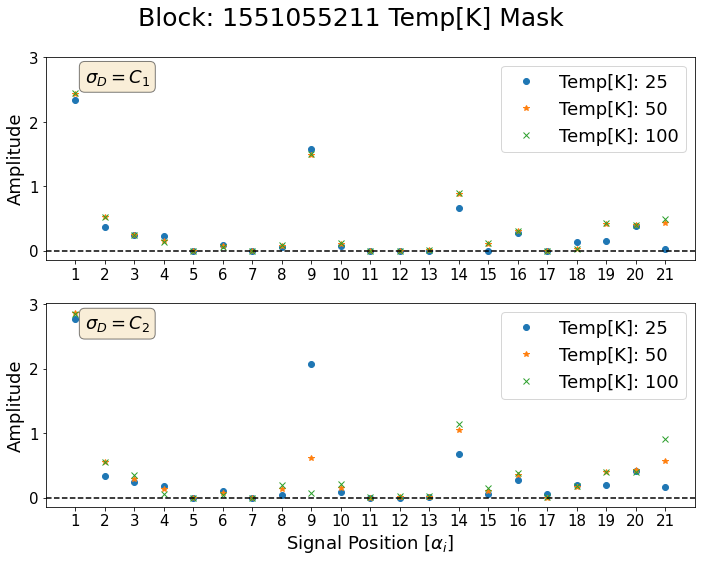

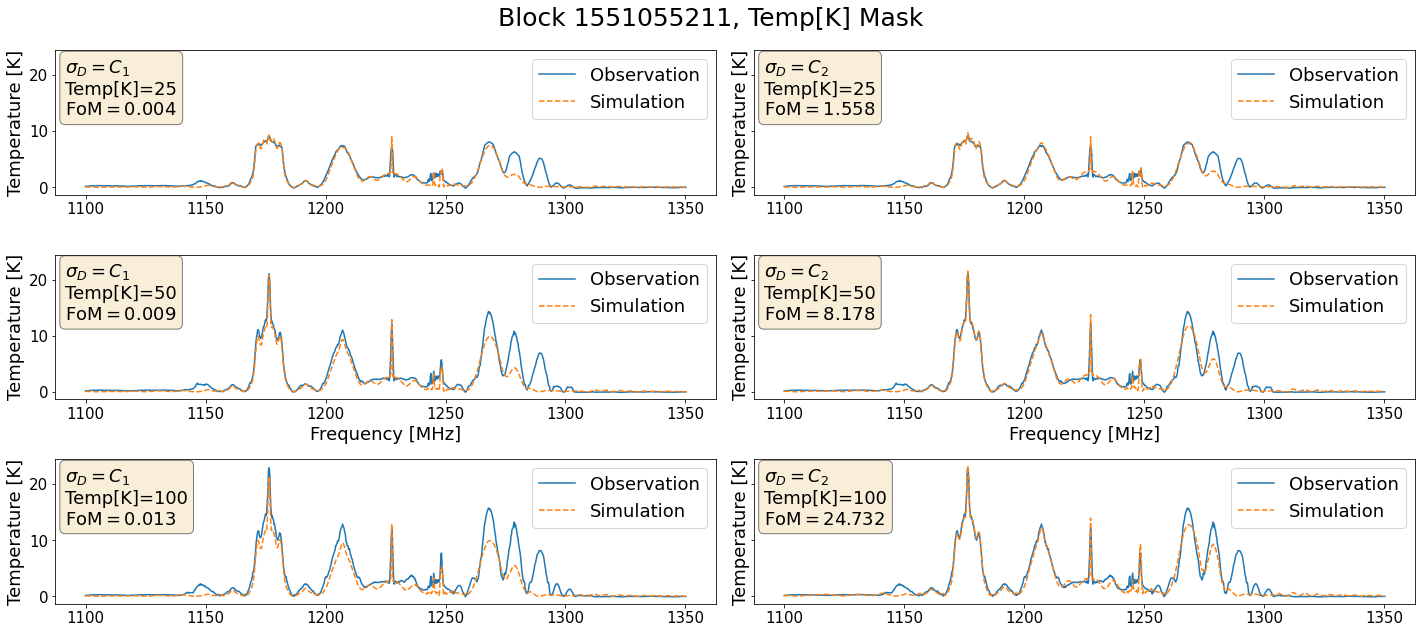

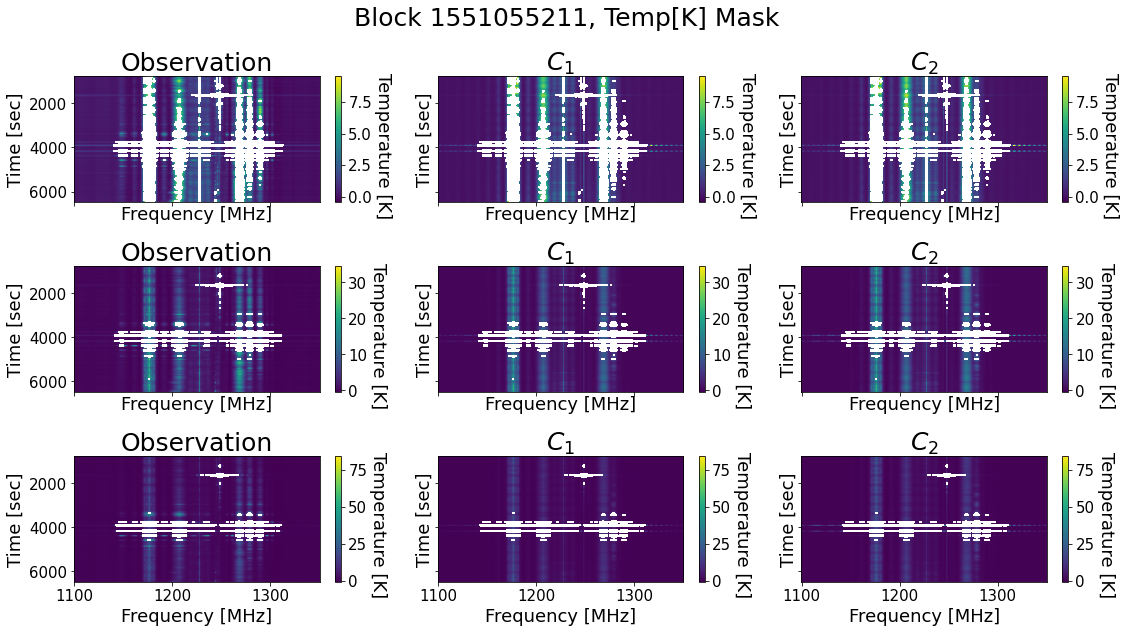

In [41]:
# showing plots
labels_mask = [25,50,100]
title = "Temp[K]"
plot_alphas(alphas_plot, labels_mask, title)
plot_1d(obs_plot, sim_plot, CF_plot, labels_mask, title)
plot_2d(obs_plot, sim_plot, labels_mask, title)

#### 3.4 Pixel-timeline Masking

In [44]:
# storing values in arrays
alphas_plot = {}
sim_plot = {}
CF_plot = {}
obs_plot = {}

for pix in [2,5,7]:
    # creating simulation object
    print(f"Simulating for pixel-timeline mask {pix}... ",end="")
    sat = simulate(pix=pix)
    obs_plot[pix] = np.ma.masked_equal(sat.observations_sat.T,0)
    print("done")
    
    for CF in ["C1","C2"]:
        # calculating
        alphas = pickle.load( open(pm.my_name(CF,pix=pix),'rb') )["best-fit"]
        sat.execute(alphas)
    
        # saving values
        if CF=="C1": 
            alphas_plot[pix] = [alphas]
            sim_plot[pix] = [np.ma.masked_equal(sat.simulation.T,0)]
            CF_plot[pix] = [sim.CF_radiometer(alphas,sat) / sat.mask[sat.mask].size]
        elif CF=="C2":  
            alphas_plot[pix].append(alphas)
            sim_plot[pix].append(np.ma.masked_equal(sat.simulation.T,0))
            CF_plot[pix].append(sim.CF_unweighted(alphas,sat) / sat.mask[sat.mask].size )
            

Simulating for pixel-timeline mask 2... done
Simulating for pixel-timeline mask 5... done
Simulating for pixel-timeline mask 7... done


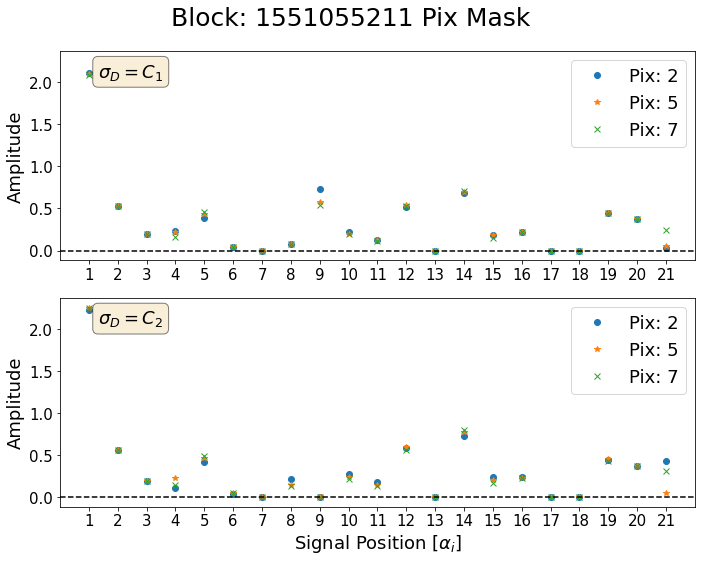

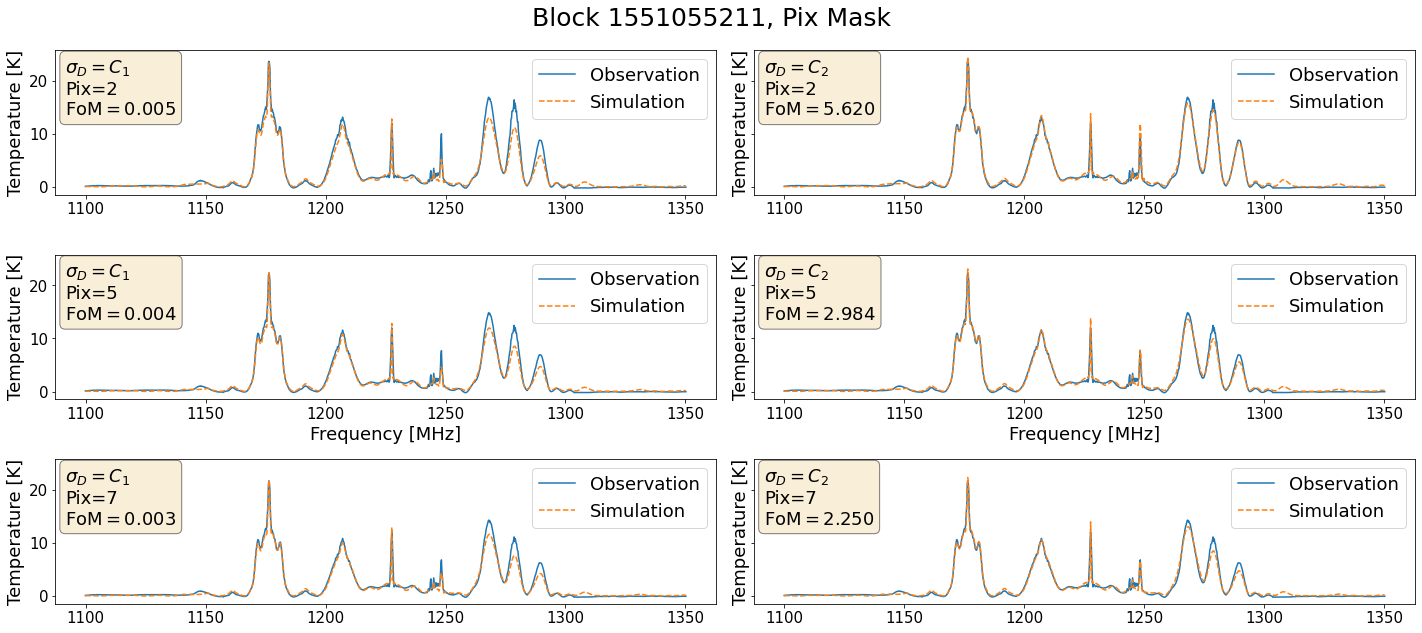

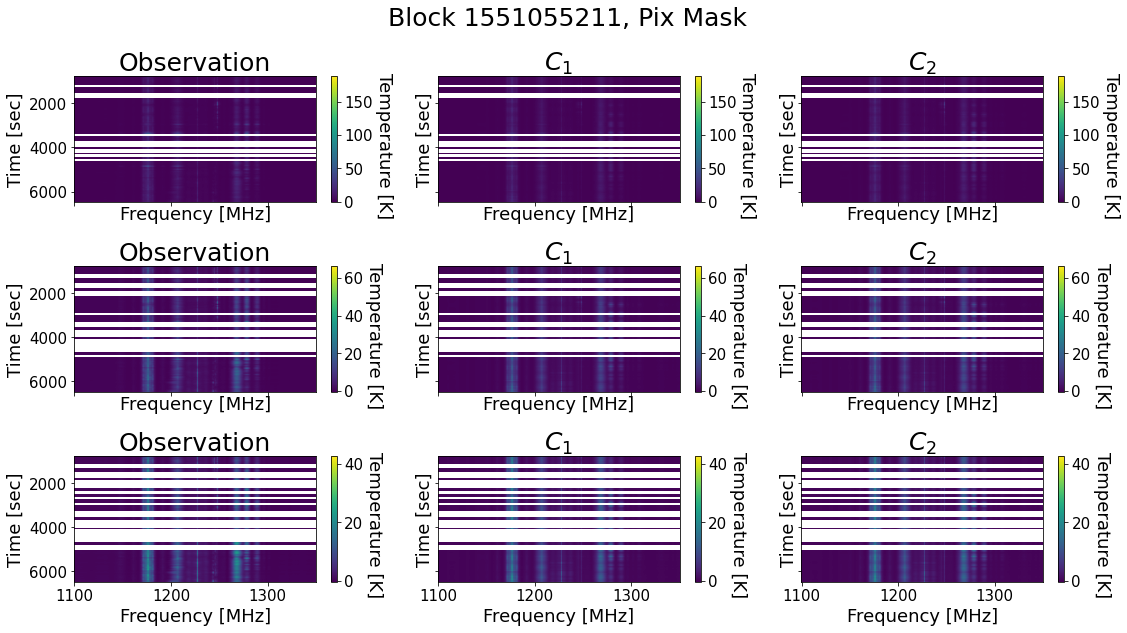

In [45]:
# showing plots
labels_mask = [2,5,7]
title = "Pix"
plot_alphas(alphas_plot, labels_mask, title)
plot_1d(obs_plot, sim_plot, CF_plot, labels_mask, title)
plot_2d(obs_plot, sim_plot, labels_mask, title)

#### 3.5 Time slicing

Falta acabar estes gráficos...